In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [11]:
# Load the original RFM dataset
rfm = pd.read_csv("../data/processed/rfm_dataset.csv")

# Load the scaled dataset
scaled_rfm = pd.read_csv("../data/processed/scaled_rfm.csv")

print("Original RFM Shape:", rfm.shape)
print("Scaled RFM Shape:", scaled_rfm.shape)

Original RFM Shape: (4338, 4)
Scaled RFM Shape: (4338, 3)


In [3]:
wcss = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_rfm)

    wcss.append(model.inertia_)

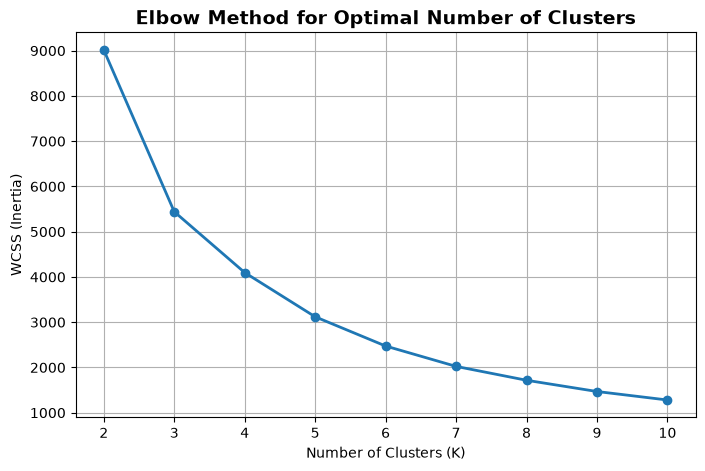

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)

plt.show()

In [7]:
silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_rfm)

    score = silhouette_score(
        scaled_rfm,
        labels
    )

    silhouette_scores.append(score)

In [8]:
silhouette_df = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

print(silhouette_df)

    K  Silhouette Score
0   2          0.895825
1   3          0.594223
2   4          0.616228
3   5          0.616500
4   6          0.598289
5   7          0.516532
6   8          0.485874
7   9          0.478438
8  10          0.479244


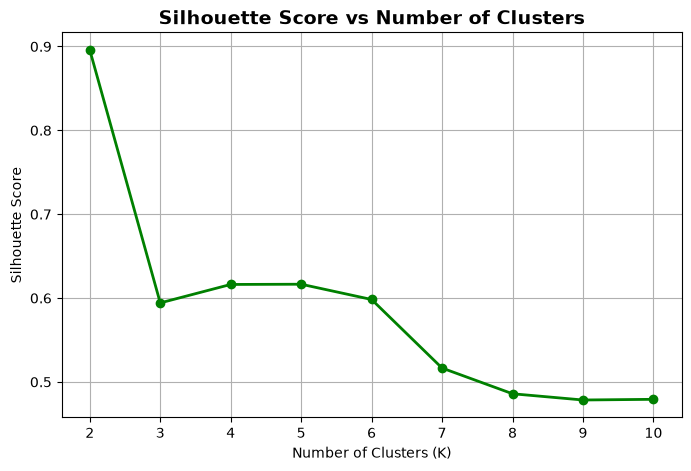

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title(
    "Silhouette Score vs Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_rfm)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [13]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64


In [14]:
cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.92,3.65,1333.13
1,248.47,1.55,478.65
2,6.50,120.50,55099.49
3,15.67,21.29,12813.94
4,7.67,42.83,190808.54


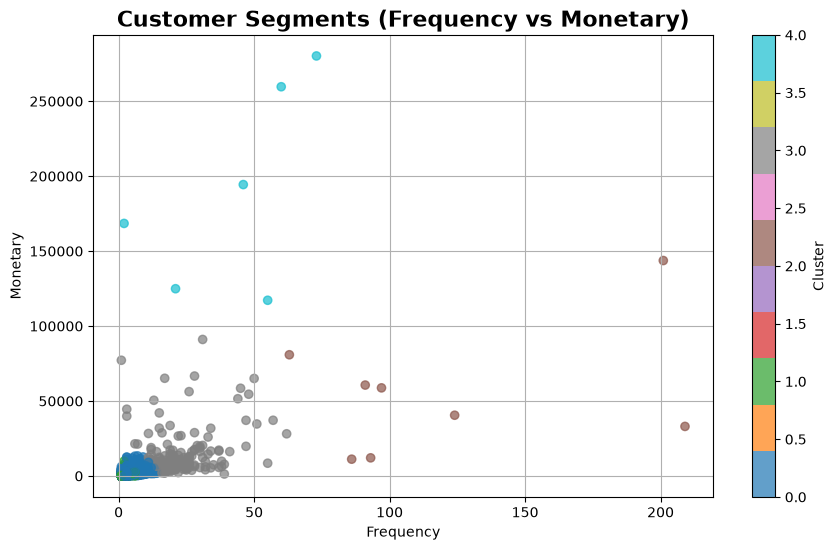

In [15]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.title(
    "Customer Segments (Frequency vs Monetary)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.grid(True)

plt.colorbar(scatter, label="Cluster")

plt.show()

In [16]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

print("KMeans model saved successfully!")

KMeans model saved successfully!


In [17]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!


In [18]:
cluster_labels = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "Loyal Customers",
    3: "High-Value Customers",
    4: "Premium Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,High-Value Customers
1,12347.0,2,7,4310.00,0,Regular Customers
2,12348.0,75,4,1797.24,0,Regular Customers
3,12349.0,19,1,1757.55,0,Regular Customers
4,12350.0,310,1,334.40,1,At-Risk Customers


In [19]:
rfm["Segment"].value_counts()

Segment
Regular Customers       3048
At-Risk Customers       1063
High-Value Customers     213
Loyal Customers            8
Premium Customers          6
Name: count, dtype: int64

| Segment              | Characteristics                             | Business Strategy                                   |
| -------------------- | ------------------------------------------- | --------------------------------------------------- |
| Regular Customers    | Moderate purchase frequency and spending    | Encourage repeat purchases with loyalty rewards     |
| At-Risk Customers    | Long time since last purchase, low spending | Re-engagement campaigns, discount coupons           |
| Loyal Customers      | Very frequent buyers                        | VIP membership, early product access                |
| High-Value Customers | High spending and frequent purchases        | Personalized offers, premium support                |
| Premium Customers    | Extremely high spenders                     | Dedicated account management, exclusive experiences |


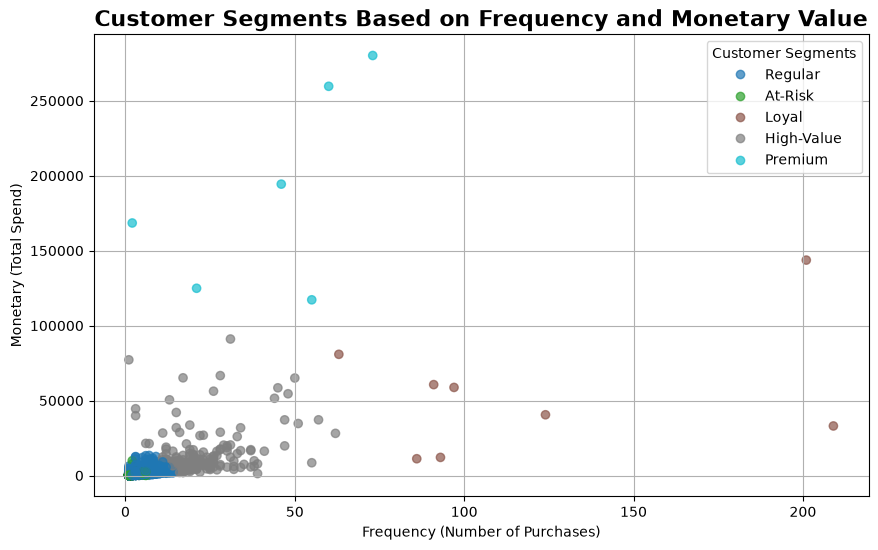

In [20]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.title(
    "Customer Segments Based on Frequency and Monetary Value",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Frequency (Number of Purchases)")
plt.ylabel("Monetary (Total Spend)")
plt.grid(True)

legend_labels = [
    "Regular",
    "At-Risk",
    "Loyal",
    "High-Value",
    "Premium"
]

handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    legend_labels,
    title="Customer Segments",
    loc="best"
)

plt.show()

In [21]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!
